In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Settings
# -----------------------
Ns = [20, 40, 80, 120, 160]
tau = 0.8  # success threshold for SFCC

COLOR_TRAIN = "#5B8DB8"   # soft blue
COLOR_TEST  = "#E6A57E"   # soft orange
def load_npz_safe(path):
    return np.load(path) if os.path.exists(path) else None

data = {}
for N in Ns:
    temp_tr = load_npz_safe(f"temperature_boxplot_trainN{N}.npz")
    temp_te = load_npz_safe(f"temperature_boxplot_testN{N}.npz")
    sfcc_tr = load_npz_safe(f"sfcc_boxplot_trainN{N}.npz")
    sfcc_te = load_npz_safe(f"sfcc_boxplot_testN{N}.npz")

    data[N] = {
        "temp_train_rmse": None if temp_tr is None else temp_tr["rmse"],
        "temp_train_r2":   None if temp_tr is None else temp_tr["r2"],
        "temp_test_rmse":  None if temp_te is None else temp_te["rmse"],
        "temp_test_r2":    None if temp_te is None else temp_te["r2"],
        "sfcc_train_rmse": None if sfcc_tr is None else sfcc_tr["rmse_allT"],
        "sfcc_train_r2":   None if sfcc_tr is None else sfcc_tr["r2_allT"],
        "sfcc_test_rmse":  None if sfcc_te is None else sfcc_te["rmse_allT"],
        "sfcc_test_r2":    None if sfcc_te is None else sfcc_te["r2_allT"],
    }

def add_box(ax, values, pos, color, width=0.22):
    """Add a colored boxplot at given position. Ignore if values is None."""
    if values is None:
        return None
    values = np.asarray(values)
    values = values[~np.isnan(values)]
    if values.size == 0:
        return None
    bp = ax.boxplot(
        [values],
        positions=[pos],
        widths=width,
        patch_artist=True,
        showfliers=False
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.0)
    for k in ["whiskers", "caps", "medians"]:
        for line in bp[k]:
            line.set_color("black")
            line.set_linewidth(1.0)
    for flier in bp["fliers"]:
        flier.set_marker("o")
        flier.set_markerfacecolor("white")
        flier.set_markeredgecolor("black")
        flier.set_markersize(4)
        flier.set_alpha(0.9)
    return bp

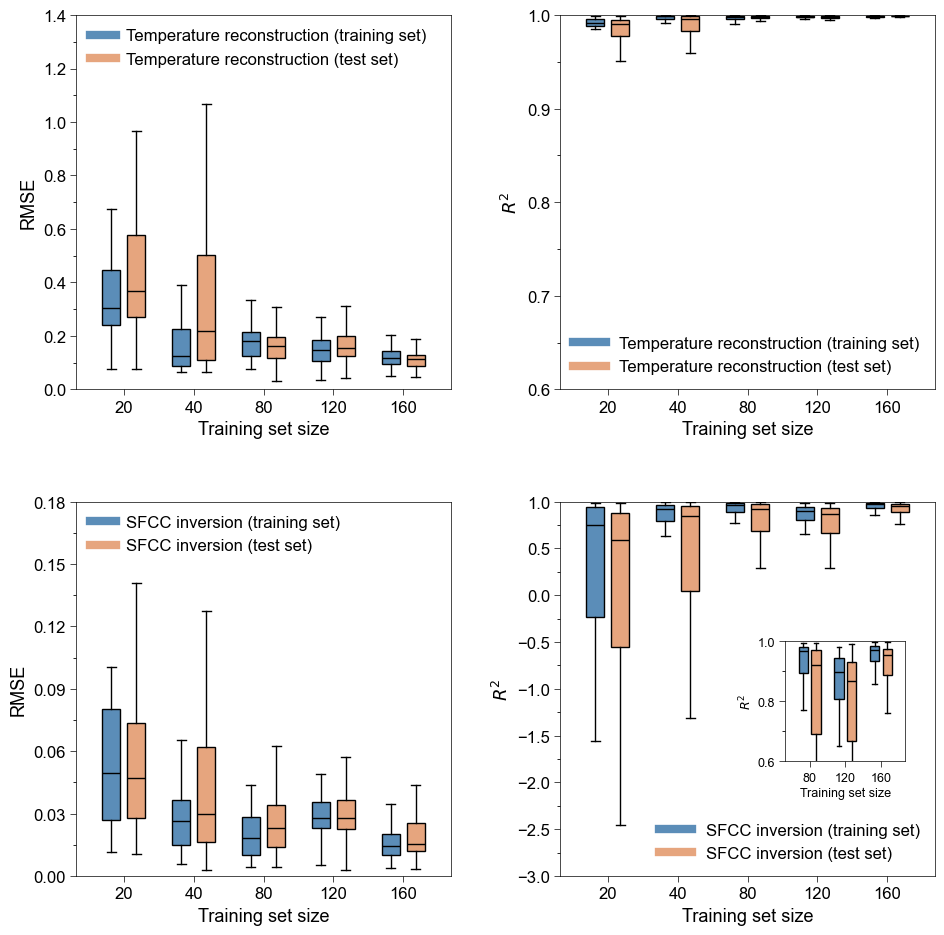

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -----------------------
# Global style
# -----------------------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

def beautify_ax(ax):
    # Full box frame (Nature-acceptable)
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.5)

    ax.tick_params(length=4, width=0.5, direction="out")
    ax.set_box_aspect(1)

def clamp_text_y(ax, y, frac=0.03):
    ymin, ymax = ax.get_ylim()
    return min(y + frac*(ymax - ymin), ymax - 0.01*(ymax - ymin))

# -----------------------
# Figure layout (force alignment)
# -----------------------
fig = plt.figure(figsize=(10.5, 10.5))  
gs = GridSpec(2, 2, figure=fig, wspace=0.10, hspace=0.30)

axs = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
])


fig.subplots_adjust(left=0.10, right=0.98, bottom=0.08, top=0.90)

x = np.arange(len(Ns)) + 1
offset = 0.18     
bar_w  = 0.30

# -----------------------
# (1) Temperature RMSE (box)
# -----------------------
ax = axs[0, 0]
for i, N in enumerate(Ns):
    add_box(ax, data[N]["temp_train_rmse"], x[i]-offset, COLOR_TRAIN, width=0.26)
    add_box(ax, data[N]["temp_test_rmse"],  x[i]+offset, COLOR_TEST,  width=0.26)

#ax.set_title("Temperature RMSE", pad=6)
ax.set_ylabel("RMSE")
ax.set_ylim(0.0, 1.4)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_xlabel("Training set size")
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in Ns])
beautify_ax(ax)

axs[0, 0].legend(
    handles=[
        plt.Line2D([0], [0], color=COLOR_TRAIN, lw=6),
        plt.Line2D([0], [0], color=COLOR_TEST,  lw=6),
    ],
    labels=["Temperature reconstruction (training set)", "Temperature reconstruction (test set)"],
    loc="upper left",          
    frameon=False,             
    handlelength=1.6,
    handletextpad=0.6,
    borderpad=0.3
)


# -----------------------
# (2) Temperature R2 (bars, median)
# -----------------------
ax = axs[0, 1]
for i, N in enumerate(Ns):
    add_box(ax, data[N]["temp_train_r2"], x[i]-offset, COLOR_TRAIN, width=0.26)
    add_box(ax, data[N]["temp_test_r2"],  x[i]+offset, COLOR_TEST,  width=0.26)

ax.set_ylabel(r"$R^2$")
ax.set_ylim(0.6, 1.00)   
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.set_xlabel("Training set size")
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in Ns])
beautify_ax(ax)

axs[0, 1].legend(
    handles=[
        plt.Line2D([0], [0], color=COLOR_TRAIN, lw=6),
        plt.Line2D([0], [0], color=COLOR_TEST,  lw=6),
    ],
    labels=["Temperature reconstruction (training set)","Temperature reconstruction (test set)"],
    loc="lower right",
    frameon=False,
)


# -----------------------
# (3) SFCC inverse RMSE (box)
# -----------------------
ax = axs[1, 0]
for i, N in enumerate(Ns):
    add_box(ax, data[N]["sfcc_train_rmse"], x[i]-offset, COLOR_TRAIN, width=0.26)
    add_box(ax, data[N]["sfcc_test_rmse"],  x[i]+offset, COLOR_TEST,  width=0.26)

#ax.set_title("SFCC Inverse RMSE (All T)", pad=6)
ax.set_ylabel("RMSE")
ax.set_ylim(0.0, 0.18)
ax.yaxis.set_major_locator(MultipleLocator(0.03))
ax.yaxis.set_minor_locator(MultipleLocator(0.015))
ax.set_xlabel("Training set size")
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in Ns])
beautify_ax(ax)

axs[1, 0].legend(
    handles=[
        plt.Line2D([0], [0], color=COLOR_TRAIN, lw=6),
        plt.Line2D([0], [0], color=COLOR_TEST,  lw=6),
    ],
    labels=["SFCC inversion (training set)", "SFCC inversion (test set)"],
    loc="upper left",         
    frameon=False,             
    handlelength=1.6,
    handletextpad=0.6,
    borderpad=0.3
)


# -----------------------
# (4) SFCC success probability (bars)
# -----------------------
ax = axs[1, 1]
for i, N in enumerate(Ns):
    add_box(ax, data[N]["sfcc_train_r2"], x[i]-offset, COLOR_TRAIN, width=0.26)
    add_box(ax, data[N]["sfcc_test_r2"],  x[i]+offset, COLOR_TEST,  width=0.26)

ax.set_ylabel(r"$R^2$")
ax.set_ylim(-3, 1.00)   
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.25))
ax.set_xlabel("Training set size")
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in Ns])
beautify_ax(ax)

axs[1, 1].legend(
    handles=[
        plt.Line2D([0], [0], color=COLOR_TRAIN, lw=6),
        plt.Line2D([0], [0], color=COLOR_TEST,  lw=6),
    ],
    labels=["SFCC inversion (training set)",
            "SFCC inversion (test set)"],
    loc="lower right",
    frameon=False,
)

ax = axs[1, 1]
# ---- inset: SFCC R2 for N = 80, 120, 160 ----
axins = inset_axes(
    ax,
    width="40%",     
    height="40%",    
    loc="lower right", 
    bbox_to_anchor=(0.02, 0.28, 0.96, 0.80),  # (x0, y0, w, h) in axes fraction
    bbox_transform=ax.transAxes,
    borderpad=0.6
)

Ns_zoom = [80, 120, 160]
x_zoom = np.arange(len(Ns_zoom)) + 1

for i, N in enumerate(Ns_zoom):
    add_box(axins, data[N]["sfcc_train_r2"], x_zoom[i]-offset,
            COLOR_TRAIN, width=0.26)
    add_box(axins, data[N]["sfcc_test_r2"],  x_zoom[i]+offset,
            COLOR_TEST,  width=0.26)

axins.set_ylim(0.6, 1.0)   
axins.yaxis.set_major_locator(MultipleLocator(0.2))   
axins.yaxis.set_minor_locator(MultipleLocator(0.1))   
axins.set_xlabel("Training set size", fontsize=9, labelpad=2)
axins.set_ylabel(r"$R^2$", fontsize=9, labelpad=2)
axins.set_xticks(x_zoom)
axins.set_xticklabels([str(n) for n in Ns_zoom], fontsize=9)
axins.tick_params(axis="y", labelsize=9)

beautify_ax(axins)


# -----------------------
# Global legend (top center)
# -----------------------
handles = [
    plt.Line2D([0], [0], color=COLOR_TRAIN, lw=10),
    plt.Line2D([0], [0], color=COLOR_TEST,  lw=10),
]
#fig.legend(handles, ["Train", "Test"],
           #loc="upper center", ncol=2, frameon=False,
           #bbox_to_anchor=(0.5, 0.975))

plt.show()